<a href="https://colab.research.google.com/github/luisgonzalez4/FPDS/blob/main/nyquist_shanon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejemplo de "aliasing"


En este código se muestra el efecto de "aliasing" al muestrear una señal analógica.
Empezamos generando nuesto vector de tiempo para la señal analógica, con $t\in[0,16]$ seg. y $dt=0.001$ seg.
Nota: para simular una señal analógica el diferencial de tiempo debe ser muy chico.
Y finalmente se simula la función:
\begin{equation}
f(t)=sin(ωt)
\end{equation}
con $f=1$ Hz

Text(0.5, 1.0, 'Señal analógica')

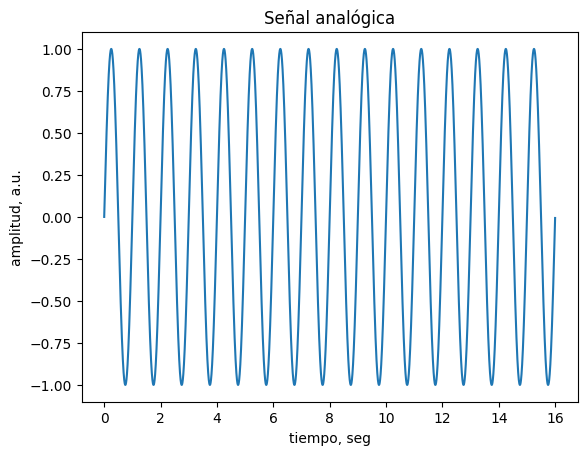

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
t=np.arange(0,16,0.001)
f=1 # frecuancia de la señal en Hz
x_a=np.sin(2*np.pi*f*t)
plt.plot(t,x_a)
plt.xlabel('tiempo, seg')
plt.ylabel('amplitud, a.u.')
plt.title('Señal analógica')


Ahora muestreamos la señal analógica con una frecuencia de muestreo de 0.9 Hz., por lo que el period de muestreo es
\begin{equation}
T=1/F_s
\end{equation}
y creamos el vector $kT$ donde $k\in[0,int(t_{max}/T)]$ es un numero veces que cabe el periodo de muestreo en toda la ventana.

En el resultado note como la señal muestreada (representada por la linea negra) posee una frecuencia de repetición distinta a la señal analógica. El aliasing (o solapamiento) es un error de distorsión que ocurre cuando una señal continua se convierte en digital usando una frecuencia de muestreo demasiado baja. De forma que las frecuencias altas se hacen pasar por frecuencias bajas.

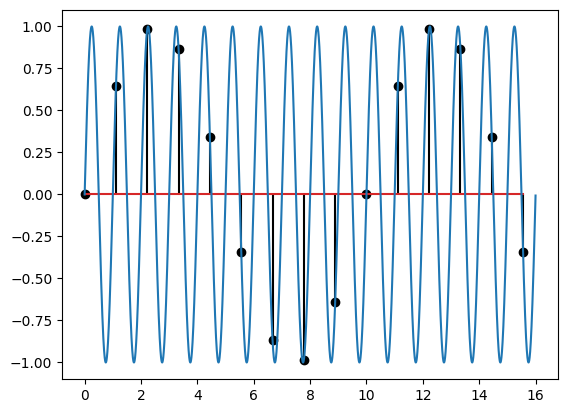

In [ ]:
Fs=0.9 # frecuencia de muestreo
kT=np.arange(0,16,1/Fs)
k=np.arange(0,len(kT))
xk=np.sin(2*np.pi*k/Fs)
plt.stem(kT,xk,'k')
plt.plot(t,x_a)


Veamos ahora un ejemplo empleando el Teorema de Nyquist-shanon. Recordando que el teorema indica que para que una señal analógica mantenga si frecuancia al ser muestreada, la frecuencia de muestreo debe ser mayor al doble de la frecuancia máxima de la señal:
\begin{equation}
f_{s}\geq 2f_{max}
\end{equation}
Entonces, si la frecuencia máxima de la señal en este caso es de $1$ Hz, la frecuencia minima para evitar el aliasing (o la frecuancia de Nyquist) es de $2$ Hz para este caso.
Ahora bien, para este caso todos los multiplos de $\pi$ la función $x_{a}(t)$ vale cero, por lo que nos combiene aumentar la frecuancia de muestreo ligeramente para evitar que $x[k]$ vaga cero para cualquier valor, por ejemplo $f_s=2.5$ Hz

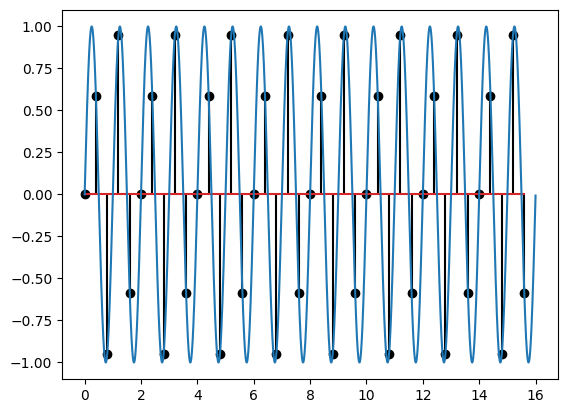

In [ ]:
Fs=2.5 # frecuencia de Nyquist
kT=np.arange(0,16,1/Fs)
k=np.arange(0,len(kT))
xk=np.sin(2*np.pi*k/Fs)
plt.stem(kT,xk,'k')
plt.plot(t,x_a)
